In [1]:
# ==========================================
# CELL 1: Environment Setup & System Imports
# ==========================================

# 1. Install required packages
!pip install --force-reinstall "numpy==1.26.4" "pandas==2.0.3" --break-system-packages
!pip install yfinance Pillow matplotlib imageio torch torchvision --break-system-packages

# 2. System and Environment utilities
import os
import sys
import time

  Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl.metadata (114 kB)
  Using cached pandas-2.0.3-cp311-cp311-macosx_11_0_arm64.whl.metadata (18 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached pytz-2026.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl (14.0 MB)
Using cached pandas-2.0.3-cp311-cp311-macosx_11_0_arm64.whl (10.7 MB)
Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl (229 kB)
Using cached pytz-2026.2-py2.py3-none-any.whl (510 kB)
Using cached tzdata-2026.2-py2.py3-none-any.whl (349 kB)
Using cached six-1.17.0-py2.py3-none-any.whl (11 kB)
  Attempting uninstall: pytz
    Found existing installation: pytz 2026.2
    Uninstalling pytz-2026.2:
      Successfully uninstalled pytz-2026.2
  Attempting uninstall: tzdata
    Fou

In [2]:
# ==============================================================================
# CELL 2: Project Architecture Imports
# ==============================================================================
import os

# Data Analysis Stack
import numpy as np
import pandas as pd
import yfinance as yf

# Deep Learning Framework
import torch
import torchvision
from torch.utils.data import TensorDataset, DataLoader

# Computer Vision & Image Processing
import imageio
from PIL import Image, ImageDraw, ImageFont

# Data Visualization
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

/Users/sivnaseth/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


# 1. Data Preprocessing

## 1. Upload data

In [1]:
!nvidia-smi

Sun Apr 12 14:46:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.133.07             Driver Version: 570.133.07     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090        Off |   00000000:A1:00.0 Off |                  N/A |
| 63%   63C    P0            325W /  350W |    3067MiB /  24576MiB |     92%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import yfinance as yf
import pandas as pd

# 1. Fetch the data
gold = yf.Ticker('GLD').history(start='2005-01-01', end='2025-12-31')
gold = gold[['Open', 'High', 'Low', 'Close', 'Volume']].copy()

# Keep a snapshot of the original data so we can see what changes
original_gold = gold.copy()

# 2. Recorrect High and Low 
gold['High'] = gold[['High', 'Open', 'Close']].max(axis=1)
gold['Low'] = gold[['Low', 'Open', 'Close']].min(axis=1)

# 3. Track the changes
# Find rows where the new High is different from the old High
fixed_highs = gold[gold['High'] != original_gold['High']]
# Find rows where the new Low is different from the old Low
fixed_lows = gold[gold['Low'] != original_gold['Low']]

print(f"Total Highs corrected: {len(fixed_highs)}")
print(f"Total Lows corrected: {len(fixed_lows)}\n")

if not fixed_highs.empty or not fixed_lows.empty:
    print("Example of a corrected row (Original vs Corrected):")
    # Let's grab the first date that got fixed
    first_fixed_date = (pd.concat([fixed_highs, fixed_lows])).index[0]
    
    print("\n--- ORIGINAL ---")
    print(original_gold.loc[[first_fixed_date], ['Open', 'High', 'Low', 'Close']])
    print("\n--- CORRECTED ---")
    print(gold.loc[[first_fixed_date], ['Open', 'High', 'Low', 'Close']])
    print("\n")

# 4. View the final corrected data
print(gold)

Total Highs corrected: 0
Total Lows corrected: 0

                                 Open        High         Low       Close  \
Date                                                                        
2005-01-03 00:00:00-05:00   42.980000   43.169998   42.740002   43.020000   
2005-01-04 00:00:00-05:00   42.799999   42.910000   42.459999   42.740002   
2005-01-05 00:00:00-05:00   42.750000   42.880001   42.599998   42.669998   
2005-01-06 00:00:00-05:00   42.480000   42.560001   42.070000   42.150002   
2005-01-07 00:00:00-05:00   42.090000   42.389999   41.700001   41.840000   
...                               ...         ...         ...         ...   
2025-12-23 00:00:00-05:00  410.299988  413.760010  407.100006  413.640015   
2025-12-24 00:00:00-05:00  412.250000  412.630005  408.829987  411.929993   
2025-12-26 00:00:00-05:00  416.480011  418.450012  414.750000  416.739990   
2025-12-29 00:00:00-05:00  403.660004  403.760010  395.329987  398.600006   
2025-12-30 00:00:00-05:00 

## 2. Preprocessing

In [4]:
gold.info()
gold.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5282 entries, 2005-01-03 00:00:00-05:00 to 2025-12-30 00:00:00-05:00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    5282 non-null   float64
 1   High    5282 non-null   float64
 2   Low     5282 non-null   float64
 3   Close   5282 non-null   float64
 4   Volume  5282 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 247.6 KB


,Open,High,Low,Close,Volume
count,5282.000000,5282.000000,5282.000000,5282.000000,5.282000e+03
mean,136.673255,137.332253,135.955850,136.676323,9.544216e+06
std,59.370321,59.613978,59.065995,59.380642,6.726520e+06
min,41.029999,41.360001,41.020000,41.259998,3.193000e+05
25%,106.982502,107.589998,106.569998,107.115000,5.374500e+06
50%,125.174999,125.570000,124.680000,125.139999,7.937000e+06
75%,166.497501,167.125004,165.770004,166.479996,1.166142e+07
max,416.480011,418.450012,414.750000,416.739990,9.380420e+07


In [5]:
gold['Volume'] = gold['Volume'].astype(float)

In [6]:
gold.info()
gold.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5282 entries, 2005-01-03 00:00:00-05:00 to 2025-12-30 00:00:00-05:00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    5282 non-null   float64
 1   High    5282 non-null   float64
 2   Low     5282 non-null   float64
 3   Close   5282 non-null   float64
 4   Volume  5282 non-null   float64
dtypes: float64(5)
memory usage: 247.6 KB


,Open,High,Low,Close,Volume
count,5282.000000,5282.000000,5282.000000,5282.000000,5.282000e+03
mean,136.673255,137.332253,135.955850,136.676323,9.544216e+06
std,59.370321,59.613978,59.065995,59.380642,6.726520e+06
min,41.029999,41.360001,41.020000,41.259998,3.193000e+05
25%,106.982502,107.589998,106.569998,107.115000,5.374500e+06
50%,125.174999,125.570000,124.680000,125.139999,7.937000e+06
75%,166.497501,167.125004,165.770004,166.479996,1.166142e+07
max,416.480011,418.450012,414.750000,416.739990,9.380420e+07


In [7]:
# Convert index to datetime (if it's not already)
gold.index = pd.to_datetime(gold.index)
# Then sort the DataFrame by date (earliest to latest)
gold = gold.sort_index(ascending=True)

In [8]:
gold

,Open,High,Low,Close,Volume
Date,,,,,
2005-01-03 00:00:00-05:00,42.980000,43.169998,42.740002,43.020000,4750400.0
2005-01-04 00:00:00-05:00,42.799999,42.910000,42.459999,42.740002,3456800.0
2005-01-05 00:00:00-05:00,42.750000,42.880001,42.599998,42.669998,2033600.0
2005-01-06 00:00:00-05:00,42.480000,42.560001,42.070000,42.150002,2556400.0
2005-01-07 00:00:00-05:00,42.090000,42.389999,41.700001,41.840000,4492700.0
...,...,...,...,...,...
2025-12-23 00:00:00-05:00,410.299988,413.760010,407.100006,413.640015,13193300.0
2025-12-24 00:00:00-05:00,412.250000,412.630005,408.829987,411.929993,6718400.0
2025-12-26 00:00:00-05:00,416.480011,418.450012,414.750000,416.739990,10476200.0


In [9]:
gold.isna().sum()

Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [10]:
# Compute 20-day Moving Average on the Close price
gold['MA20'] = gold['Close'].rolling(window=20).mean()
gold = gold.dropna(subset=['MA20'])

In [11]:
passes = []

# Train is strictly a rolling 10-year window
train_starts = [2005, 2005, 2005, 2005, 2005, 2005, 2005, 2005, 2005, 2005]
train_ends   = [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
# 1-year validation immediately after trainin
val_starts   = [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
val_ends     = [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
# 1-year testing immediately after validatio
test_starts  = [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
test_ends    = [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

def slice_period(df, start_year, end_year):
    return df[(df.index.year >= start_year) & (df.index.year <= end_year)]

for i in range(len(train_starts)):
    # 1. Base Slices
    train_df = slice_period(gold, train_starts[i], train_ends[i])
    val_df   = slice_period(gold, val_starts[i],   val_ends[i])
    test_df_original = slice_period(gold, test_starts[i],  test_ends[i])
    
    # 2. STITCH ONLY VAL -> TEST
    lookback = 4 + 60  
    original_test_len = len(test_df_original)
    
    # Grab the last 64 days of Validation and attach to the front of Testing
    if len(val_df) >= lookback:
        test_df = pd.concat([val_df.iloc[-lookback:], test_df_original])
    else:
        test_df = test_df_original.copy()
    
    # 3. Save to passes
    passes.append({
        "pass": i+1,
        "train_years": (train_starts[i], train_ends[i]),
        "val_years":   (val_starts[i],   val_ends[i]),
        "test_years":  (test_starts[i],  test_ends[i]),
        "train_df": train_df,
        "val_df":   val_df,
        "test_df":  test_df,
        "test_orig_len": original_test_len # Storing this for the clear printout
    })

# --- VERIFICATION PRINT ---
for p in passes:
    lookback_added = len(p['test_df']) - p['test_orig_len']
    
    print(
        f"Pass {p['pass']:>2}: "
        f"Train {p['train_years'][0]}–{p['train_years'][1]}, "
        f"Val {p['val_years'][0]}–{p['val_years'][1]}, "
        f"Test {p['test_years'][0]}–{p['test_years'][1]}, "
        f"Sizes: Train={len(p['train_df'])}, Val={len(p['val_df'])}, "
        f"Test={p['test_orig_len']} + {lookback_added}"
    )

Pass  1: Train 2005–2014, Val 2015–2015, Test 2016–2016, Sizes: Train=2498, Val=252, Test=252 + 64
Pass  2: Train 2005–2015, Val 2016–2016, Test 2017–2017, Sizes: Train=2750, Val=252, Test=251 + 64
Pass  3: Train 2005–2016, Val 2017–2017, Test 2018–2018, Sizes: Train=3002, Val=251, Test=251 + 64
Pass  4: Train 2005–2017, Val 2018–2018, Test 2019–2019, Sizes: Train=3253, Val=251, Test=252 + 64
Pass  5: Train 2005–2018, Val 2019–2019, Test 2020–2020, Sizes: Train=3504, Val=252, Test=253 + 64
Pass  6: Train 2005–2019, Val 2020–2020, Test 2021–2021, Sizes: Train=3756, Val=253, Test=252 + 64
Pass  7: Train 2005–2020, Val 2021–2021, Test 2022–2022, Sizes: Train=4009, Val=252, Test=251 + 64
Pass  8: Train 2005–2021, Val 2022–2022, Test 2023–2023, Sizes: Train=4261, Val=251, Test=250 + 64
Pass  9: Train 2005–2022, Val 2023–2023, Test 2024–2024, Sizes: Train=4512, Val=250, Test=252 + 64
Pass 10: Train 2005–2023, Val 2024–2024, Test 2025–2025, Sizes: Train=4762, Val=252, Test=249 + 64


## 2. Simple Return for Normalize Image

- Using Backward Simple Return for Image normalization
- As for our prediction is 5-day horizon, removing the last 5.

In [12]:
for p in passes:

    # --- TRAIN ---
    X_train_df = p["train_df"].copy()
    X_train_df['Return'] = (X_train_df['Close'].shift(-59) - X_train_df['Close']) / X_train_df['Close']
    X_train_df['Return'] = X_train_df['Return'].shift(59)

    # DROP Last 5 rows
    X_train_df = X_train_df.iloc[:-5]

    # Save
    p["X_train_df"] = X_train_df

    # --- VALIDATION ---
    X_val_df = p["val_df"].copy()
    X_val_df['Return'] = (X_val_df['Close'].shift(-59) - X_val_df['Close']) / X_val_df['Close']
    X_val_df['Return'] = X_val_df['Return'].shift(59)

    # DROP Last 5 rows
    X_val_df = X_val_df.iloc[:-5]

    # Save
    p["X_val_df"] = X_val_df


    # --- TEST ---
    X_test_df = p["test_df"].copy()
    X_test_df['Return'] = (X_test_df['Close'].shift(-59) - X_test_df['Close']) / X_test_df['Close']
    X_test_df['Return'] = X_test_df['Return'].shift(59)

    # DROP Last 5 rows
    X_test_df = X_test_df.iloc[:-5]

    # Save
    p["X_test_df"] = X_test_df


In [13]:
X_train_p = {}
X_val_p = {}
X_test_p = {}

for i in range(len(passes)):
    X_train_p[i+1] = passes[i]["X_train_df"]
    X_val_p[i+1]   = passes[i]["X_val_df"]
    X_test_p[i+1]  = passes[i]["X_test_df"]

In [14]:
X_train_p

{1:                                  Open        High         Low       Close  \
 Date                                                                        
 2005-01-31 00:00:00-05:00   42.209999   42.299999   41.959999   42.220001   
 2005-02-01 00:00:00-05:00   42.090000   42.139999   41.950001   42.099998   
 2005-02-02 00:00:00-05:00   42.220001   42.230000   42.020000   42.160000   
 2005-02-03 00:00:00-05:00   41.560001   41.740002   41.500000   41.680000   
 2005-02-04 00:00:00-05:00   41.590000   41.650002   41.389999   41.470001   
 ...                               ...         ...         ...         ...   
 2014-12-17 00:00:00-05:00  115.099998  115.480003  113.580002  114.269997   
 2014-12-18 00:00:00-05:00  115.589996  115.809998  114.580002  115.150002   
 2014-12-19 00:00:00-05:00  115.059998  115.220001  114.769997  114.769997   
 2014-12-22 00:00:00-05:00  114.809998  114.970001  112.410004  112.550003   
 2014-12-23 00:00:00-05:00  112.879997  113.320000  112.61000

In [15]:
save_dir = "X_splits"
os.makedirs(save_dir, exist_ok=True)

for p in range(1, len(passes)+1):
    X_train_p[p].to_csv(os.path.join(save_dir, f"pass{p}_train.csv"))
    X_val_p[p].to_csv(os.path.join(save_dir, f"pass{p}_val.csv"))
    X_test_p[p].to_csv(os.path.join(save_dir, f"pass{p}_test.csv"))

print("✅ Saved all X_train_p, X_val_p, X_test_p as CSV.")

✅ Saved all X_train_p, X_val_p, X_test_p as CSV.


## Visual

In [16]:
X_train_p[1]

,Open,High,Low,Close,Volume,MA20,Return
Date,,,,,,,
2005-01-31 00:00:00-05:00,42.209999,42.299999,41.959999,42.220001,1692400.0,42.4450,NaN
2005-02-01 00:00:00-05:00,42.090000,42.139999,41.950001,42.099998,1088900.0,42.3990,NaN
2005-02-02 00:00:00-05:00,42.220001,42.230000,42.020000,42.160000,956500.0,42.3700,NaN
2005-02-03 00:00:00-05:00,41.560001,41.740002,41.500000,41.680000,2446400.0,42.3205,NaN
2005-02-04 00:00:00-05:00,41.590000,41.650002,41.389999,41.470001,1819400.0,42.2865,NaN
...,...,...,...,...,...,...,...
2014-12-17 00:00:00-05:00,115.099998,115.480003,113.580002,114.269997,9097300.0,115.5345,-0.023751
2014-12-18 00:00:00-05:00,115.589996,115.809998,114.580002,115.150002,5258100.0,115.6080,-0.019082
2014-12-19 00:00:00-05:00,115.059998,115.220001,114.769997,114.769997,4652300.0,115.6035,-0.019563


In [17]:
X_train_p[1].head(60)

,Open,High,Low,Close,Volume,MA20,Return
Date,,,,,,,
2005-01-31 00:00:00-05:00,42.209999,42.299999,41.959999,42.220001,1692400.0,42.4450,NaN
2005-02-01 00:00:00-05:00,42.090000,42.139999,41.950001,42.099998,1088900.0,42.3990,NaN
2005-02-02 00:00:00-05:00,42.220001,42.230000,42.020000,42.160000,956500.0,42.3700,NaN
2005-02-03 00:00:00-05:00,41.560001,41.740002,41.500000,41.680000,2446400.0,42.3205,NaN
2005-02-04 00:00:00-05:00,41.590000,41.650002,41.389999,41.470001,1819400.0,42.2865,NaN
2005-02-07 00:00:00-05:00,41.549999,41.549999,41.209999,41.270000,1754000.0,42.2580,NaN
2005-02-08 00:00:00-05:00,41.189999,41.400002,41.049999,41.259998,1296800.0,42.2235,NaN
2005-02-09 00:00:00-05:00,41.029999,41.360001,41.020000,41.310001,3477900.0,42.1785,NaN
2005-02-10 00:00:00-05:00,41.529999,41.840000,41.450001,41.750000,7774500.0,42.1360,NaN


In [18]:
window_size = 60
feature_cols = ['Close','Volume','High','Low','Open','MA20','Close_Original','Return']

def build_tensor_from_df(df, window_size=60, feature_cols=None):
    if feature_cols is None:
        feature_cols = ['Close','Volume','High','Low','Open','MA20','Close_Original','Return']
    
    # 1) Work on a copy
    df_proc = df.copy()

    # 2) Insert duplicate of Close right after MA20 → Close_Original
    if "MA20" in df_proc.columns and "Close" in df_proc.columns and "Close_Original" not in df_proc.columns:
        df_proc.insert(
            df_proc.columns.get_loc("MA20") + 1,
            "Close_Original",
            df_proc["Close"]
        )

    # 3) Keep only the features we care about (and that exist)
    cols = [c for c in feature_cols if c in df_proc.columns]
    if not cols:
        return {
            "X_image": np.empty((0, window_size, 0), dtype=np.float32),
            "cols": [],
            "window_size": window_size,
            "rows_used": 0,
            "num_samples": 0
        }

    df_proc = df_proc[cols]          # you can add .bfill().ffill() if needed
    F = df_proc.to_numpy(dtype=np.float32)  # (N, Fdim)
    N, Fdim = F.shape

    # 4) number of samples: you used N - window_size + 1
    S = N - window_size +1
    if S <= 0:
        return {
            "X_image": np.empty((0, window_size, Fdim), dtype=np.float32),
            "cols": cols,
            "window_size": window_size,
            "rows_used": N,
            "num_samples": 0
        }

    # 5) Sliding windows (S, window_size, Fdim)
    X = np.stack([F[i:i+window_size] for i in range(S)], axis=0)

    # 6) Overwrite 'Close' with compounded path, keep Close_Original
    if 'Close' in cols:
        price_idx = cols.index('Close')
        close = X[:, :, price_idx]  # (S, window_size)

        r_step = np.zeros_like(close)
        r_step[:, 1:] = (close[:, 1:] / close[:, :-1]) - 1.0

        P = np.ones_like(close)
        P[:, 1:] = np.cumprod(1.0 + r_step[:, 1:], axis=1)

        X[:, :, price_idx] = P

    # 7) Transform columns 2,3,4,5 using Close_Original (col 6) and Close (col 0)
    #    (follow your original logic, but safer with index lookups)
    if 'Close_Original' in cols:
        idx_close_orig = cols.index('Close_Original')
        idx_close = cols.index('Close') if 'Close' in cols else None

        for k in [2, 3, 4, 5]:  # High, Low, Open, MA20 (according to feature_cols order)
            if k < Fdim and idx_close is not None:
                X[:, :, k] = (X[:, :, k] / X[:, :, idx_close_orig]) * X[:, :, idx_close]

    # 8) Drop Close_Original & Return (indices 6 and 7 in your design)
    col_to_drop = []
    if 'Close_Original' in cols:
        col_to_drop.append(cols.index('Close_Original'))
    if 'Return' in cols:
        col_to_drop.append(cols.index('Return'))

    if col_to_drop:
        X = np.delete(X, col_to_drop, axis=2)
        # also drop names from cols list
        cols_clean = [c for i, c in enumerate(cols) if i not in col_to_drop]
    else:
        cols_clean = cols

    return {
        "X_image": X,
        "cols": cols_clean,
        "window_size": window_size,
        "rows_used": N,
        "num_samples": S,
    }

In [19]:
X_train_img_p = {}
X_val_img_p   = {}
X_test_img_p  = {}

for k in range(1, len(passes)+1):   # passes 1 → 10
    print(f"\n📊 Building tensors for PASS {k}...")

    # TRAIN
    train_res = build_tensor_from_df(X_train_p[k], window_size=60, feature_cols=feature_cols)
    X_train_img_p[k] = train_res["X_image"]
    print(f"  ✅ Train: shape = {train_res['X_image'].shape}, features = {len(train_res['cols'])}")

    # VAL
    val_res = build_tensor_from_df(X_val_p[k], window_size=60, feature_cols=feature_cols)
    X_val_img_p[k] = val_res["X_image"]
    print(f"  ✅ Val:   shape = {val_res['X_image'].shape}, features = {len(val_res['cols'])}")

    # TEST
    test_res = build_tensor_from_df(X_test_p[k], window_size=60, feature_cols=feature_cols)
    X_test_img_p[k] = test_res["X_image"]
    print(f"  ✅ Test:  shape = {test_res['X_image'].shape}, features = {len(test_res['cols'])}")


📊 Building tensors for PASS 1...
  ✅ Train: shape = (2434, 60, 6), features = 6
  ✅ Val:   shape = (188, 60, 6), features = 6
  ✅ Test:  shape = (252, 60, 6), features = 6

📊 Building tensors for PASS 2...
  ✅ Train: shape = (2686, 60, 6), features = 6
  ✅ Val:   shape = (188, 60, 6), features = 6
  ✅ Test:  shape = (251, 60, 6), features = 6

📊 Building tensors for PASS 3...
  ✅ Train: shape = (2938, 60, 6), features = 6
  ✅ Val:   shape = (187, 60, 6), features = 6
  ✅ Test:  shape = (251, 60, 6), features = 6

📊 Building tensors for PASS 4...
  ✅ Train: shape = (3189, 60, 6), features = 6
  ✅ Val:   shape = (187, 60, 6), features = 6
  ✅ Test:  shape = (252, 60, 6), features = 6

📊 Building tensors for PASS 5...
  ✅ Train: shape = (3440, 60, 6), features = 6
  ✅ Val:   shape = (188, 60, 6), features = 6
  ✅ Test:  shape = (253, 60, 6), features = 6

📊 Building tensors for PASS 6...
  ✅ Train: shape = (3692, 60, 6), features = 6
  ✅ Val:   shape = (189, 60, 6), features = 6
  ✅ Test

In [20]:
df = X_train_p[1]     # choose any pass

result = build_tensor_from_df(df)

S = result["num_samples"]
N = result["rows_used"]
window_size = result["window_size"]

# ---- FIRST WINDOW ----
start_idx_first = 0
end_idx_first   = window_size - 1

first_window_start_date = df.index[start_idx_first]
first_window_end_date   = df.index[end_idx_first]

print("FIRST window uses rows :", start_idx_first, "→", end_idx_first)
print("FIRST window start date:", first_window_start_date)
print("FIRST window end date  :", first_window_end_date)

# ---- LAST WINDOW (your previous version) ----
start_idx_last = S - 1
end_idx_last   = start_idx_last + window_size - 1

last_window_start_date = df.index[start_idx_last]
last_window_end_date   = df.index[end_idx_last]

print("\nLAST window uses rows  :", start_idx_last, "→", end_idx_last)
print("LAST window start date :", last_window_start_date)
print("LAST window end date   :", last_window_end_date)

FIRST window uses rows : 0 → 59
FIRST window start date: 2005-01-31 00:00:00-05:00
FIRST window end date  : 2005-04-26 00:00:00-04:00

LAST window uses rows  : 2433 → 2492
LAST window start date : 2014-09-30 00:00:00-04:00
LAST window end date   : 2014-12-23 00:00:00-05:00


In [21]:
X_train_p[1].tail(11)

,Open,High,Low,Close,Volume,MA20,Return
Date,,,,,,,
2014-12-09 00:00:00-05:00,117.040001,118.989998,116.980003,118.190002,10467200.0,114.640001,-0.005386
2014-12-10 00:00:00-05:00,118.150002,118.470001,117.809998,117.959999,4277400.0,114.936000,0.003573
2014-12-11 00:00:00-05:00,116.980003,118.379997,116.820000,117.690002,5214500.0,115.245501,-0.000764
2014-12-12 00:00:00-05:00,117.389999,117.800003,116.680000,117.410004,4736500.0,115.532501,0.002733
2014-12-15 00:00:00-05:00,116.220001,116.970001,114.360001,114.389999,8796000.0,115.528501,-0.021053
2014-12-16 00:00:00-05:00,116.279999,116.500000,114.070000,114.949997,9174000.0,115.573500,-0.022534
2014-12-17 00:00:00-05:00,115.099998,115.480003,113.580002,114.269997,9097300.0,115.534500,-0.023751
2014-12-18 00:00:00-05:00,115.589996,115.809998,114.580002,115.150002,5258100.0,115.608000,-0.019082
2014-12-19 00:00:00-05:00,115.059998,115.220001,114.769997,114.769997,4652300.0,115.603500,-0.019563


In [22]:
# ----------------------------- helpers -----------------------------
def _normalize(arr, eps=1e-9):
    arr = np.asarray(arr, dtype=float)
    lo, hi = float(arr.min()), float(arr.max())
    if hi - lo < eps:
        return np.zeros_like(arr)
    return (arr - lo) / (hi - lo)

# -------------------- main renderer (grayscale) --------------------
def ohlc_with_ma_volume(
    open_, high, low, close,
    volume=None, ma=None,
    px_per_bar=3,
    margin_px=2,
    H=96,
    price_to_vol_ratio=(4,1),   # top:bottom split
    wick_w=1,
    tick_w=1,
    tick_len=1,                 # open/close tick length
    extend_ma_frac=0.2,
    fg=255, bg=0
):
    """
    Minimal OHLC bars (wick center; open tick left; close tick right) + MA + slim volume.
    Draws on an (H, W) canvas, then crops 2 px from left and right -> final shape (96, 180).
    """
    open_, high, low, close = map(lambda a: np.asarray(a, float), (open_, high, low, close))
    n = len(close)
    assert len(open_) == len(high) == len(low) == n

    # Layout (native draw width)
    W = n * px_per_bar + 2 * margin_px
    if volume is not None:
        p, v = price_to_vol_ratio
        price_H = int(round(H * (p / (p + v))))
        vol_H   = H - price_H
    else:
        price_H = H
        vol_H   = 0
    y0_price, y0_vol = 0, price_H

    # Canvas
    img = Image.new("L", (W, H), color=bg)
    draw = ImageDraw.Draw(img)

    # Y-scale for price
    lo_min = float(low.min()); hi_max = float(high.max())
    pad = (hi_max - lo_min) * 0.03
    lo_min -= pad; hi_max += pad
    rng = max(hi_max - lo_min, 1e-9)

    def ypix(v):
        t = (v - lo_min) / rng
        t = 0.0 if t < 0 else 1.0 if t > 1 else t
        return y0_price + (price_H - 1) - int(round(t * (price_H - 1)))

    # X centers
    cx = np.arange(n) * px_per_bar + margin_px + px_per_bar // 2

    # OHLC bars (wick + ticks)
    for i in range(n):
        x = int(cx[i])
        yH, yL = ypix(high[i]), ypix(low[i])
        yO, yC = ypix(open_[i]), ypix(close[i])
        draw.line([(x, yH), (x, yL)], fill=fg, width=wick_w)                 # wick
        draw.line([(x - tick_len, yO), (x, yO)], fill=fg, width=tick_w)      # open (left)
        draw.line([(x, yC), (x + tick_len, yC)], fill=fg, width=tick_w)      # close (right)

    # MA line (optional)
    if ma is not None:
        ma = np.asarray(ma, float)
        pts = [(int(cx[i]), ypix(ma[i])) for i in range(n)]
        dx = px_per_bar * extend_ma_frac
        left_ext  = (int(round(cx[0] - dx+1)), ypix(ma[0]))
        right_ext = (int(round(cx[-1] + dx-1)), ypix(ma[-1]))
        pts = [left_ext] + pts + [right_ext]
        for a, b in zip(pts[:-1], pts[1:]):
            draw.line([a, b], fill=fg, width=1)

    # Volume: slim centered line per day
    if volume is not None and vol_H > 0:
        vol = np.asarray(volume, float)
        norm = _normalize(vol)
        for i in range(n):
            x = int(cx[i])
            h = int(round(norm[i] * (vol_H - 1)))
            h = max(h, 1)
            y_bottom = y0_vol + vol_H - 1
            y_top    = y_bottom - h
            draw.line([(x, y_bottom), (x, y_top)], fill=fg, width=1)

    # --- return as array, then crop 2 px from left & right -> (64, 60) ---
    arr = np.array(img, dtype=np.uint8)
    # # only crop if width >= 96; remove exactly 2 px on both sides
    if arr.shape[1] >= 96:
        arr = arr[:, 2:-2]  # (H, W-4) -> if W was 64, becomes 60
    # If somehow wider than 180 originally, center-crop to 60 for safety:
    if arr.shape[1] > 180:
        start = (arr.shape[1] - 180) // 2
        arr = arr[:, start:start + 180]
    return arr  # final (64, 60)

# ------------------------ small batch + preview ------------------------
def make_batch(commodity_features, n_samples=10):
    imgs = []
    for name, tensors in commodity_features.items():
        X_image_train = tensors["X_image_train"]
        for idx in range(len(X_image_train)):
            close, vol, high, low, open_, ma = X_image_train[idx,:,0], X_image_train[idx,:,1], X_image_train[idx,:,2], X_image_train[idx,:,3], X_image_train[idx,:,4], X_image_train[idx,:,5]
            arr = ohlc_with_ma_volume(open_, high, low, close, volume=vol, ma=ma, H=96, px_per_bar=3, margin_px=2)
            imgs.append(arr)
            if len(imgs) >= n_samples:
                return imgs
    return imgs

def preview_grid(imgs, ncols=5, scale=6):
    if not imgs:
        print("No images to preview."); return
    n = len(imgs)
    nrows = (n + ncols - 1) // ncols
    plt.figure(figsize=(ncols * scale, nrows * scale))
    for i, arr in enumerate(imgs):
        plt.subplot(nrows, ncols, i + 1)
        plt.imshow(arr, cmap="gray", vmin=0, vmax=255)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

def preview_grid(imgs, ncols=5, scale=4):
    """
    Show images in a grid with bigger display size.
    scale controls how large each image cell looks.
    """
    if not imgs:
        print("No images to preview."); return
    n = len(imgs)
    nrows = (n + ncols - 1) // ncols
    plt.figure(figsize=(ncols * scale, nrows * scale))
    for i, arr in enumerate(imgs):
        plt.subplot(nrows, ncols, i + 1)
        plt.imshow(arr, cmap="gray", vmin=0, vmax=255)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

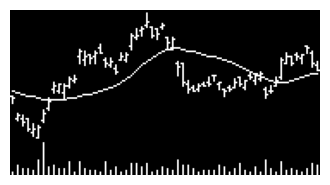

In [23]:
# Take one window from pass 10
w = X_train_img_p[1][2]          # shape (5, 6)

# Unpack columns: [Close, Volume, High, Low, Open, MA20]
close = w[:, 0]
vol   = w[:, 1]
high  = w[:, 2]
low   = w[:, 3]
open_ = w[:, 4]
ma    = w[:, 5]

# Use your renderer to make ONE image
img = ohlc_with_ma_volume(
    open_, high, low, close,
    volume=vol,
    ma=ma,
    H=96,
    px_per_bar=3,
    margin_px=2
)

# Show it
plt.figure(figsize=(4, 4))
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()

Numbered GIF saved as: pass1_animation_numbered.gif


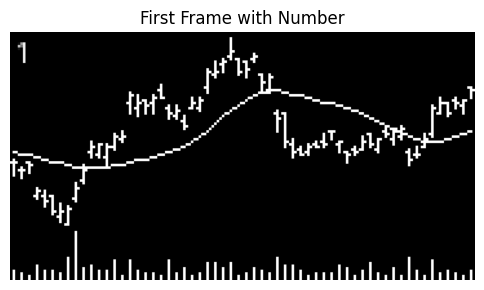

In [24]:
N_frames = 50
frames = []

SCALE = 12   

for idx in range(N_frames):
    w = X_train_img_p[1][idx] 

    # Unpack columns
    close = w[:, 0]
    vol   = w[:, 1]
    high  = w[:, 2]
    low   = w[:, 3]
    open_ = w[:, 4]
    ma    = w[:, 5]

    # Render raw (small) image
    img_small = ohlc_with_ma_volume(
        open_, high, low, close,
        volume=vol, ma=ma,
        H=96, px_per_bar=3, margin_px=2
    )

    # Convert to PIL
    img_pil = Image.fromarray(img_small)

    # --- NEW: Add Sample Number ---
    # Ensure image is in a mode that supports color/grayscale drawing (L=grayscale, RGB=Color)
    # If your source is float 0-1, you might need to normalize to uint8 0-255 first.
    # Assuming img_small is already uint8 0-255 here based on your plt code.
    if img_pil.mode != 'RGB':
        img_pil = img_pil.convert('RGB') # Convert to RGB to ensure colored text works

    draw = ImageDraw.Draw(img_pil)
    
    # Text, Position (x=2, y=2), and Color (White)
    # Note: Default font is used. For specific fonts use ImageFont.truetype()
    draw.text((2, 2), f"{idx + 1}", fill=(255, 255, 255)) 
    # ------------------------------

    # BIG upscale (nearest keeps the sharp pixel aesthetic)
    W_big = img_small.shape[1] * SCALE
    H_big = img_small.shape[0] * SCALE
    img_big = img_pil.resize((W_big, H_big), resample=Image.NEAREST)

    frames.append(np.array(img_big))

# Save as GIF
gif_path = "pass1_animation_numbered.gif"
imageio.mimsave(gif_path, frames, duration=0.3)

print("Numbered GIF saved as:", gif_path)

# Display first frame to verify
plt.figure(figsize=(6, 6))
plt.imshow(frames[0]) # No cmap needed if we converted to RGB
plt.axis("off")
plt.title("First Frame with Number")
plt.show()

In [25]:
# Base folder for all images
base_dir = "charts_passes"
os.makedirs(base_dir, exist_ok=True)

num_passes = len(passes)

for k in range(1, num_passes + 1):  # pass 1..10
    
    print(f"\n📊 PASS {k}: Processing train/val/test...")

    # --------------- LOOP OVER SPLITS -----------------
    for split_name, X_split in [
        ("train", X_train_img_p[k]),
        ("val",   X_val_img_p[k]),
        ("test",  X_test_img_p[k])
    ]:

        S = X_split.shape[0]

        # Make directory for this pass and split
        out_dir = os.path.join(base_dir, f"pass{k}", split_name)
        os.makedirs(out_dir, exist_ok=True)

        print(f"   ➤ {split_name} : {S} windows")

        for idx in range(S):
            w = X_split[idx]  # shape (5, 6)

            # Unpack OHLCVMA
            close = w[:, 0]
            vol   = w[:, 1]
            high  = w[:, 2]
            low   = w[:, 3]
            open_ = w[:, 4]
            ma    = w[:, 5]

            # Render OHLC+MA+Volume chart
            img_arr = ohlc_with_ma_volume(
                open_, high, low, close,
                volume=vol,
                ma=ma,
                H=96,
                px_per_bar=3,
                margin_px=2
            )

            # Save PNG
            img_pil = Image.fromarray(img_arr)
            fname = f"pass{k}_{split_name}_{idx:05d}.png"
            fpath = os.path.join(out_dir, fname)
            img_pil.save(fpath)

        print(f"   ✅ Saved {S} images to {out_dir}")

print("\n🎉 ALL PASSES COMPLETED — IMAGES SAVED IN 'charts_passes/'")


📊 PASS 1: Processing train/val/test...
   ➤ train : 2434 windows
   ✅ Saved 2434 images to charts_passes/pass1/train
   ➤ val : 188 windows
   ✅ Saved 188 images to charts_passes/pass1/val
   ➤ test : 252 windows
   ✅ Saved 252 images to charts_passes/pass1/test

📊 PASS 2: Processing train/val/test...
   ➤ train : 2686 windows
   ✅ Saved 2686 images to charts_passes/pass2/train
   ➤ val : 188 windows
   ✅ Saved 188 images to charts_passes/pass2/val
   ➤ test : 251 windows
   ✅ Saved 251 images to charts_passes/pass2/test

📊 PASS 3: Processing train/val/test...
   ➤ train : 2938 windows
   ✅ Saved 2938 images to charts_passes/pass3/train
   ➤ val : 187 windows
   ✅ Saved 187 images to charts_passes/pass3/val
   ➤ test : 251 windows
   ✅ Saved 251 images to charts_passes/pass3/test

📊 PASS 4: Processing train/val/test...
   ➤ train : 3189 windows
   ✅ Saved 3189 images to charts_passes/pass4/train
   ➤ val : 187 windows
   ✅ Saved 187 images to charts_passes/pass4/val
   ➤ test : 252 wi